# Fashion MNIST Classification with MLP

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/Intro2DL/blob/main/04_Fashion_MNIST_MLP_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [1]:
# Colab이나 Kaggle을 사용하는 경우가 아니면, 이 cell을 모두 주석화하여 skip할 것.
# Colab 런타임 유형을 반드시 GPU로 선택할 것.
import os

repository_name = 'Intro2DL'
repository_url = f'https://github.com/kikim6114/{repository_name}.git'

# 항상 루트 경로(/content/)로 이동 후 확인
%cd /content/

if not os.path.exists(repository_name):
    !git clone {repository_url}
    print(f"{repository_name} 클론 완료")
else:
    print(f"{repository_name} 폴더가 이미 존재합니다. 클론을 건너뜁니다.")
%cd {repository_name}

/content
Cloning into 'Intro2DL'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 36 (delta 1), reused 5 (delta 1), pack-reused 30 (from 1)
Receiving objects: 100% (36/36), 59.22 MiB | 14.19 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Intro2DL 클론 완료
/content/Intro2DL


In [2]:
!pip install torchinfo

In [3]:
import torch
from torch import nn
from torchinfo import summary
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt  # 시각화를 위한 라이브러리 추가

## 1. 데이터셋 로드 및 전처리
#### MNIST 같은 grayscale 이미지 [0, 255] --> [-1. 1] 값으로 정규화
- transforms.Normalize(mean=(0.5,), std=(0.5,))
#### ImageNet의 칼라 이미지 정규화: RGB 각 채널의 평균과 표준편차를 기반으로 설정
- transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

In [4]:
BATCH_SIZE = 256
EPOCHS = 100
LEARNING_RATE = 0.05
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
#
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Using device: cuda


100%|██████████████████████████████████████████████████| 26421880/26421880 [00:13<00:00, 1973782.14it/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|█████████████████████████████████████████████████████████| 29515/29515 [00:00<00:00, 110913.30it/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|████████████████████████████████████████████████████| 4422102/4422102 [00:02<00:00, 1689862.65it/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████████████████████████████████████████████████████| 5148/5148 [00:00<00:00, 5153288.06it/s]

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



## 2. 2개의 은닉층을 가진 모델 정의 (Deep MLP)

In [5]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(DEVICE)

summary(model, input_size=(BATCH_SIZE, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [256, 10]                 --
├─Flatten: 1-1                           [256, 784]                --
├─Linear: 1-2                            [256, 256]                200,960
├─ReLU: 1-3                              [256, 256]                --
├─Linear: 1-4                            [256, 128]                32,896
├─ReLU: 1-5                              [256, 128]                --
├─Linear: 1-6                            [256, 10]                 1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
Total mult-adds (M): 60.20
Input size (MB): 0.80
Forward/backward pass size (MB): 0.81
Params size (MB): 0.94
Estimated Total Size (MB): 2.55

### 모델 가중치 초기화

In [6]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.zeros_(m.bias)

model.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)

## 3. 손실 함수와 최적화 알고리즘

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

## 4. 모델 훈련 및 지표 기록

In [8]:
num_epochs = EPOCHS

# 지표를 저장할 빈 리스트 생성
history_loss = []
history_train_acc = []
history_test_acc = []

print("Training Started...")

Training Started...


In [ ]:
for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        y_hat = model(X)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)
        train_correct += (y_hat.argmax(dim=1) == y).sum().item()
        train_total += y.size(0)
    model.eval()
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            y_hat = model(X)
            test_correct += (y_hat.argmax(dim=1) == y).sum().item()
            test_total += y.size(0)

    # 에포크별 결과 계산
    epoch_loss = train_loss / train_total
    train_acc = train_correct / train_total
    test_acc = test_correct / test_total

    # 계산된 결과를 리스트에 저장
    history_loss.append(epoch_loss)
    history_train_acc.append(train_acc)
    history_test_acc.append(test_acc)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch + 1:02d} | Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}')

print("Training Finished!")

Epoch 01 | Loss: 1.8046 | Train Acc: 0.3710 | Test Acc: 0.5677
Epoch 10 | Loss: 0.4011 | Train Acc: 0.8545 | Test Acc: 0.8263


## 5. 결과 시각화 (Plotting the Metrics)

In [1]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# 첫 번째 그래프: 훈련 손실(Loss) 추이
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_loss, marker='o', color='red', label='Train Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
# 두 번째 그래프: 훈련 및 테스트 정확도(Accuracy) 추이
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_train_acc, marker='o', color='blue', label='Train Accuracy')
plt.plot(epochs_range, history_test_acc, marker='s', color='green', label='Test Accuracy')
plt.title('Training vs Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'num_epochs' is not defined

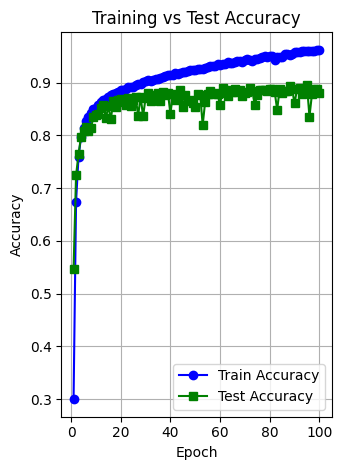

In [11]:
# 두 번째 그래프: 훈련 및 테스트 정확도(Accuracy) 추이
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_train_acc, marker='o', color='blue', label='Train Accuracy')
plt.plot(epochs_range, history_test_acc, marker='s', color='green', label='Test Accuracy')
plt.title('Training vs Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
